# L10b: Sentiment Classification with Precomputed GloVe Embeddings
In this lab, we use precomputed [GloVe (Global Vectors for Word Representation)](https://nlp.stanford.edu/projects/glove/) embeddings to classify synthetic product reviews by sentiment. We represent each review as the mean of its word vectors, then train a feedforward neural network to predict whether a review is positive, negative, or neutral. This lab connects the embedding ideas from L9-L10a to the feedforward classification approach from L8d.

> __Learning Objectives__
>
> * __Represent text using precomputed GloVe embeddings:__ Load a pretrained GloVe embedding matrix and convert variable-length text reviews into fixed-length feature vectors by averaging word vectors. Identify which words in the corpus are covered by the GloVe vocabulary and which are out-of-vocabulary.
> * __Train a feedforward neural network for sentiment classification:__ Construct a multi-layer feedforward network in [Flux.jl](https://fluxml.ai/Flux.jl/stable/) that maps 100-dimensional GloVe feature vectors to three sentiment classes. Train the model using cross-entropy loss and gradient descent with momentum.
> * __Evaluate classifier performance using accuracy and confusion matrices:__ Compute training and test accuracy to assess generalization. Use a confusion matrix to identify which sentiment classes are most frequently confused by the model.

Let's get started!

___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading GloVe embeddings, generating the review dataset, and preparing the feature matrix for classification.

> [The `include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

In [1]:
include("Include.jl"); # load packages, paths, and local source files

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Implementations

The notebook uses the following functions:

| Function | Location | Description |
|----------|----------|-------------|
| [`download_glove(datapath; dim)`](src/GloVeUtils.jl) | `src/GloVeUtils.jl` | Downloads Stanford GloVe 6B embeddings and returns the path to the text file |
| [`load_glove_embeddings(filepath)`](src/GloVeUtils.jl) | `src/GloVeUtils.jl` | Parses a GloVe text file into a `Dict{String, Vector{Float32}}` |
| [`generate_quantumbrew_reviews(; n_per_class, seed)`](src/Reviews.jl) | `src/Reviews.jl` | Generates synthetic QuantumBrew Coffee reviews with sentiment labels |
| [`embed_review(review, glove; dim)`](src/Embeddings.jl) | `src/Embeddings.jl` | Computes the mean GloVe vector for a single review |
| [`embed_reviews(reviews, glove; dim)`](src/Embeddings.jl) | `src/Embeddings.jl` | Embeds a vector of reviews into a `(dim x n)` feature matrix |

The following helper functions are defined in this notebook:

In [2]:
"""
    cosine_sim(a::Vector{Float32}, b::Vector{Float32}) -> Float64

Compute the cosine similarity between two vectors.
"""
function cosine_sim(a::Vector{Float32}, b::Vector{Float32})::Float64
    return dot(a, b) / (norm(a, 2) * norm(b, 2) + eps(Float32));
end;

"""
    compute_accuracy(model, data) -> Float64

Compute classification accuracy (%) for a Flux model on a dataset of (features, one-hot label) tuples.
"""
function compute_accuracy(model, data)::Float64
    correct = 0;
    for (x, y) in data
        ŷ = argmax(model(x));
        actual = argmax(y);
        ŷ == actual ? correct += 1 : nothing;
    end
    return round(100.0 * correct / length(data), digits=2);
end;

### Constants
Next, we define constants the will be used throughout the notebook. See the comment next to each constant for its purpose. Adjust these as needed for experimentation.

In [ ]:
glove_dim = 100;            # GloVe embedding dimension
n_per_class = 250;          # number of reviews per sentiment class
review_seed = 42;           # seed for reproducible review generation
θ = 0.80;                   # fraction of data used for training
number_of_classes = 3;      # positive, negative, neutral
number_of_hidden = 64;      # hidden layer size
number_of_epochs = 100;     # training epochs
λ = 0.01;                   # learning rate
β = 0.90;                   # momentum parameter

### Data
The data for this lab consists of synthetic customer reviews for a fictional product called __QuantumBrew Coffee__. Each review is labeled with a sentiment: `positive`, `negative`, or `neutral`. The reviews are generated using the `generate_quantumbrew_reviews(...)` function, which creates varied and realistic-sounding feedback based on predefined templates (including hard reviews involving sarcasm and mixed sentiments).

> __What is QuantumBrew Coffee?__
>
> QuantumBrew is a fictional premium energy coffee that combines espresso-strength coffee with energy drink ingredients. It comes in five flavors: Classic Espresso Surge, Vanilla Lightning, Caramel Thunder, Mocha Bolt, and Hazelnut Shock. We generate synthetic customer reviews for this product with three sentiment labels: `positive`, `negative`, and `neutral`.

We generate the review dataset [using the `generate_quantumbrew_reviews(...)` function](src/Reviews.jl) with seeded random selection from sentence templates. The reviews and their sentiment labels are held in the `reviews_df::DataFrame` variable, which has columns `:review` (the review text) and `:label` (one of `"positive"`, `"negative"`, or `"neutral"`).

In [4]:
reviews_df = let

    # generate synthetic reviews -
    df = generate_quantumbrew_reviews(; n_per_class=n_per_class, seed=review_seed);
    println("Total reviews: $(nrow(df))");

    # show class distribution -
    for label in ["positive", "negative", "neutral"]
        count = sum(df.label .== label);
        println("  $label: $count");
    end

    df # return the dataframe
end;

Total reviews: 999
  positive: 333
  negative: 333
  neutral: 333


Let's look at a sample review from each sentiment class.

In [ ]:
let
    for label in ["positive", "negative", "neutral"]
        idx = findfirst(reviews_df.label .== label);
        println("[$label] $(reviews_df.review[idx])");
        println();
    end
end

[positive] I never thought an energy coffee could taste this good. I drink one every morning and it keeps me focused all day. Best purchase I have made in a long time.

[negative] Very disappointed with this product overall. It tastes like burnt coffee mixed with something medicinal. Going back to regular espresso after this.

[neutral] QuantumBrew is an okay energy coffee. The Mocha Bolt is fine but I have had better from other brands. Not something I would go out of my way to buy.



Now that we have generated our review dataset, we need a way to represent each review as a numeric vector that a neural network can process. We use pretrained GloVe embeddings for this.

> __What are precomputed GloVe embeddings?__
>
> [Stanford NLP provides GloVe vectors](https://nlp.stanford.edu/projects/glove/) pretrained on a corpus of 6 billion tokens from Wikipedia and Gigaword. Each word is mapped to a 100-dimensional vector that captures semantic relationships learned from global co-occurrence statistics. These vectors encode the property that words appearing in similar contexts have similar embeddings, so cosine similarity between vectors reflects semantic similarity between words.

We download the GloVe 6B embeddings (if not already cached) [using the `download_glove(...)` function](src/GloVeUtils.jl) and parse them into a lookup dictionary [using the `load_glove_embeddings(...)` function](src/GloVeUtils.jl). The pretrained embeddings are held in the `glove::Dict{String, Vector{Float32}}` dictionary, which maps each word to its 100-dimensional embedding vector.

In [6]:
glove = let

    # download (or locate cached) GloVe embeddings -
    glove_path = download_glove(_PATH_TO_DATA; dim=glove_dim);

    # parse the text file into a dictionary -
    embeddings = load_glove_embeddings(glove_path);
    println("GloVe vocabulary size: $(length(embeddings))");
    println("Embedding dimension: $(length(first(values(embeddings))))");

    embeddings # return the dictionary
end;

GloVe vocabulary size: 400000
Embedding dimension: 100


With the GloVe embeddings loaded, we need to convert each variable-length review into a fixed-length vector that the classifier can accept as input.

> __How do we convert variable-length text to a fixed-length feature vector?__
>
> Each review contains a different number of words, but the classifier requires a fixed-length input. We use a bag-of-embeddings approach: look up the GloVe vector for each word in the review and compute the element-wise mean. This produces a single vector $\bar{\mathbf{e}} \in \mathbb{R}^{100}$ for each review that summarizes its semantic content. Words not in the GloVe vocabulary are skipped.

We embed all reviews into a feature matrix [using the `embed_reviews(...)` function](src/Embeddings.jl) and encode sentiment labels as [one-hot vectors](https://en.wikipedia.org/wiki/One-hot) for use with cross-entropy loss. The mapping is: `positive` = 1, `negative` = 2, `neutral` = 3. The paired features and labels are held in the `dataset::Vector{Tuple{Vector{Float32}, OneHotVector{UInt32}}}` variable, where the first element of each tuple is the 100-dimensional mean embedding vector and the second element is the one-hot encoded sentiment label.

In [7]:
dataset = let

    # embed all reviews into a (dim x n) feature matrix -
    X = embed_reviews(reviews_df.review, glove; dim=glove_dim);
    println("Feature matrix size: $(size(X))  (dim x n_reviews)");

    # encode sentiment labels as one-hot vectors -
    label_map = Dict("positive" => 1, "negative" => 2, "neutral" => 3);
    class_indices = [1, 2, 3];
    data = Vector{Tuple{Vector{Float32}, OneHotVector{UInt32}}}();
    for i in 1:nrow(reviews_df)
        features = X[:, i]; # the embedding vector for review i
        label_idx = label_map[reviews_df.label[i]]; # integer class index
        label_onehot = Flux.onehot(label_idx, class_indices); # one-hot encode
        push!(data, (features, label_onehot));
    end

    println("Dataset size: $(length(data)) samples");
    data # return the dataset
end;

Feature matrix size: (100, 999)  (dim x n_reviews)
Dataset size: 999 samples


Before training, we split the dataset into separate training and test partitions so we can evaluate how well the model generalizes to unseen reviews.

> __Train-test split:__
>
> We randomly partition the dataset into training and test sets. The training set contains 80% of the data and the test set contains the remaining 20%. The split is randomized to ensure each set contains a representative mix of all three sentiment classes.

We split the data into training and test partitions. The training samples are held in the `training_dataset::Vector{Tuple{Vector{Float32}, OneHotVector{UInt32}}}` variable and the test samples in the `test_dataset::Vector{Tuple{Vector{Float32}, OneHotVector{UInt32}}}` variable. The original indices of the test samples are held in the `test_indices::Vector{Int64}` variable so we can look up the corresponding review text later.

In [8]:
training_dataset, test_dataset, test_indices = let

    # compute partition sizes -
    n_total = length(dataset);
    n_train = Int64(floor(θ * n_total));

    # shuffle and split -
    Random.seed!(review_seed);
    shuffled = shuffle(1:n_total);
    train_idx = shuffled[1:n_train];
    test_idx = shuffled[n_train+1:end];

    println("Training samples: $(length(train_idx))");
    println("Test samples: $(length(test_idx))");

    dataset[train_idx], dataset[test_idx], test_idx # return both partitions and test indices
end;

Training samples: 799
Test samples: 200


___

## Task 1: Explore GloVe Embedding Structure
Before training a classifier, we verify that the pretrained GloVe vectors capture semantic relationships relevant to sentiment analysis. We compute cosine similarities for selected word pairs and check how many of our review words are covered by the GloVe vocabulary.

> __Checking semantic structure in the pretrained embeddings:__
>
> We compute cosine similarity $\cos(\mathbf{e}_i, \mathbf{e}_j) = \mathbf{e}_i \cdot \mathbf{e}_j \,/\, (\|\mathbf{e}_i\|_{2} \, \|\mathbf{e}_j\|_{2})$ between selected word pairs to confirm that semantically related words have high similarity and unrelated words have low similarity. This is the same similarity measure used in L10a to evaluate GloVe embeddings trained from scratch.

Let's compute cosine similarities for word pairs relevant to sentiment analysis.

In [9]:
let

    # define word pairs to check -
    word_pairs = [
        ("good", "great"),
        ("terrible", "awful"),
        ("good", "bad"),
        ("love", "hate"),
        ("coffee", "espresso"),
        ("coffee", "airplane"),
        ("delicious", "tasty"),
        ("disappointing", "frustrating"),
    ];

    # compute similarities and build a DataFrame -
    w1_col = String[];
    w2_col = String[];
    sim_col = Float64[];
    for (w1, w2) in word_pairs
        push!(w1_col, w1);
        push!(w2_col, w2);
        push!(sim_col, round(cosine_sim(glove[w1], glove[w2]), digits=3));
    end
    df = DataFrame("Word 1" => w1_col, "Word 2" => w2_col, "Cosine Similarity" => sim_col);
    pretty_table(df);
end

┌───────────────┬─────────────┬───────────────────┐
│        Word 1 │      Word 2 │ Cosine Similarity │
│        String │      String │           Float64 │
├───────────────┼─────────────┼───────────────────┤
│          good │       great │             0.759 │
│      terrible │       awful │             0.874 │
│          good │         bad │              0.77 │
│          love │        hate │              0.57 │
│        coffee │    espresso │             0.664 │
│        coffee │    airplane │              0.21 │
│     delicious │       tasty │             0.863 │
│ disappointing │ frustrating │             0.638 │
└───────────────┴─────────────┴───────────────────┘


The cosine similarities above show that GloVe captures semantic relatedness: synonyms like (good, great) score high, while unrelated pairs like (coffee, airplane) score low. However, antonyms like (good, bad) may also score moderately high because they appear in similar contexts. Next, let's check how many of our review words are actually covered by the GloVe vocabulary.

> __Vocabulary coverage:__
>
> The bag-of-embeddings approach skips any word not found in the GloVe vocabulary. If many review words are out-of-vocabulary (OOV), the resulting feature vectors lose information. We check coverage to confirm that the pretrained GloVe vocabulary is sufficient for our corpus.

Let's check what fraction of our review vocabulary is covered by GloVe.

In [10]:
let

    # collect unique words from all reviews using the same tokenizer as embed_review -
    all_review_words = unique(vcat([_tokenize(r) for r in reviews_df.review]...));
    in_vocab = sum(w -> haskey(glove, w), all_review_words);
    oov = length(all_review_words) - in_vocab;

    println("Unique words in reviews: $(length(all_review_words))");
    println("In GloVe vocabulary: $in_vocab");
    println("Out-of-vocabulary: $oov");

    # show OOV words if any -
    if oov > 0
        oov_words = [w for w in all_review_words if !haskey(glove, w)];
        println("OOV words: $(join(oov_words[1:min(10, length(oov_words))], ", "))");
    end
end

Unique words in reviews: 629
In GloVe vocabulary: 623
Out-of-vocabulary: 6
OOV words: quantumbrew, mustbuy, underwhelm, lattestyle, musthave, wellbalanced


### Things to think about
* __Question:__ Antonyms like (good, bad) and (love, hate) often have moderate-to-high cosine similarity because they appear in similar syntactic contexts. Why might this be a problem for a sentiment classifier that represents reviews by averaging word vectors?

___

## Task 2: Train a Feedforward Sentiment Classifier
We construct a two-layer feedforward network that maps the 100-dimensional GloVe feature vectors to three sentiment classes, and train it using cross-entropy loss with gradient descent and momentum. This follows the same classification pattern used in L8d for credit risk prediction.

> __Feedforward network architecture:__
>
> The classifier is a two-layer feedforward network built with [`Flux.Chain`](https://fluxml.ai/Flux.jl/stable/reference/models/layers/#Flux.Chain). The first [`Dense`](https://fluxml.ai/Flux.jl/stable/reference/models/layers/#Flux.Dense) layer maps the 100-dimensional GloVe feature vector to a hidden layer with [`tanh_fast`](https://fluxml.ai/NNlib.jl/dev/reference/#NNlib.tanh_fast) activation. The second `Dense` layer maps the hidden representation to 3 output logits, one per sentiment class. A [`softmax`](https://fluxml.ai/NNlib.jl/dev/reference/#Softmax) output converts logits to predicted class probabilities.
>
> __Loss function and optimizer:__ We train the network using [cross-entropy loss](https://fluxml.ai/Flux.jl/stable/reference/models/losses/#Flux.Losses.crossentropy) $\mathcal{L}(\hat{\mathbf{p}}, \mathbf{y}) = -\sum_{j=1}^{C} y_j \log(\hat{p}_j)$ and gradient descent with [`Momentum`](https://fluxml.ai/Flux.jl/stable/reference/training/optimisers/#Optimisers.Momentum). The momentum optimizer updates parameters using an exponentially weighted average of past gradients, which helps the optimizer traverse flat regions and reduces oscillation.

We construct the model, train it (or load a pre-trained checkpoint if one exists), and record the loss history. The trained network is held in the `trained_model::Chain` variable and the per-epoch average loss values are held in the `loss_history::Vector{Float64}` variable.

In [ ]:
trained_model, loss_history = let

    # initialize the model architecture -
    local_model = Chain(
        Dense(glove_dim, number_of_hidden, tanh_fast),
        Dense(number_of_hidden, number_of_classes),
        NNlib.softmax
    );
    n_params = sum(length, Flux.trainable(local_model));
    println("Model: $(glove_dim) → $(number_of_hidden) → $(number_of_classes) → softmax");
    println("Learnable parameters: $n_params");

    # initialize -
    lh_ = nothing;

    # look for a pre-trained model file; if exists, load; if not, train -
    model_path = joinpath(_PATH_TO_DATA, "sentiment_model_H$(number_of_hidden).jld2");
    if isfile(model_path)
        println("Loading pre-trained model from $(model_path)");
        f = jldopen(model_path, "r");
        model_state = f["model_state"]; lh_ = f["loss_history"];
        close(f);
        Flux.loadmodel!(local_model, model_state);
        println("Model loaded successfully!");
    else
        println("Training sentiment classifier ($(number_of_epochs) epochs, $(length(training_dataset)) samples)...");
        opt_state = Flux.setup(Momentum(λ, β), local_model);
        lh_ = zeros(Float64, number_of_epochs);
        best_loss = Inf;
        best_state = Flux.state(local_model);
        best_epoch = 0;
        for epoch in 1:number_of_epochs
            epoch_loss = 0.0;
            Flux.train!(local_model, training_dataset, opt_state) do m, x, y
                l = Flux.Losses.crossentropy(m(x), y);
                epoch_loss += l;
                l
            end
            lh_[epoch] = epoch_loss / length(training_dataset);

            # checkpoint the best model -
            if lh_[epoch] < best_loss
                best_loss = lh_[epoch];
                best_state = deepcopy(Flux.state(local_model));
                best_epoch = epoch;
            end

            if rem(epoch, 20) == 0
                println("Epoch $epoch/$number_of_epochs — avg loss: $(round(lh_[epoch], digits=4)) (best: $(round(best_loss, digits=4)) @ epoch $best_epoch)");
            end
        end

        # restore the best model weights -
        Flux.loadmodel!(local_model, best_state);
        println("Restored best model from epoch $best_epoch (loss: $(round(best_loss, digits=4)))");

        # save the best model for future use -
        jldsave(model_path; model_state=best_state, loss_history=lh_);
        println("Model saved to $(model_path)");
    end

    local_model, lh_ # return model and loss history
end;

Let's plot the training loss to verify that the model converges.

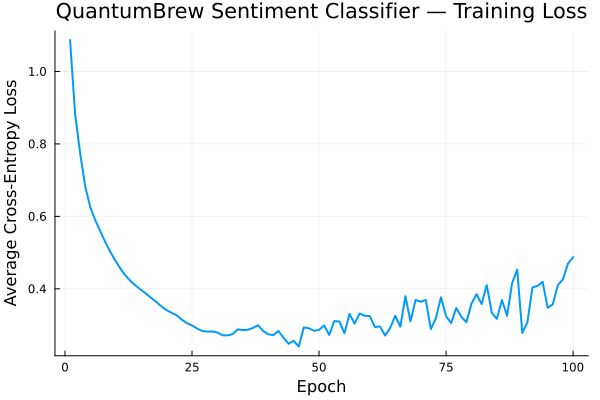

In [12]:
let
    plot(1:number_of_epochs, loss_history;
        xlabel="Epoch", ylabel="Average Cross-Entropy Loss",
        title="QuantumBrew Sentiment Classifier — Training Loss",
        legend=false, lw=2)
end

### Things to think about
* __Question:__ The loss curve may decrease and then blow up in later epochs. What causes this instability, and how does the best-model checkpointing strategy in the training loop protect against it?

___

## Task 3: Evaluate the Classifier
We assess the trained model by computing classification accuracy on both the training and test sets, examining the confusion matrix to identify which sentiment classes are most frequently confused, and inspecting misclassified reviews to understand the limitations of the bag-of-embeddings representation.

> __Computing classification accuracy:__
>
> We pass each sample through the trained model, take the `argmax` of the output probability vector as the predicted class, and compare it to the true label. The accuracy is the fraction of samples where the predicted and true classes match. We compute this separately on the training and test sets to check for overfitting.

How well does the model perform on the training dataset versus unseen test data?

In [13]:
let
    train_acc = compute_accuracy(trained_model, training_dataset);
    test_acc = compute_accuracy(trained_model, test_dataset);
    println("Training accuracy: $(train_acc)%");
    println("Test accuracy: $(test_acc)%");
    println("Gap: $(round(train_acc - test_acc, digits=2)) percentage points");
end

Training accuracy: 77.22%
Test accuracy: 78.0%
Gap: -0.78 percentage points


The accuracy numbers tell us overall performance, but they do not reveal which classes the model confuses. A confusion matrix breaks down predictions by class to show where errors concentrate.

> __Confusion matrix:__
>
> A confusion matrix is a $C \times C$ table where entry $M_{ij}$ counts how many samples with true class $i$ were predicted as class $j$. Diagonal entries are correct predictions. Off-diagonal entries reveal which classes the model confuses, indicating where the GloVe feature representation may not provide sufficient separation between sentiment categories.

We compute the confusion matrix on the test set. The results are held in the `confusion_matrix::DataFrame` variable, where rows correspond to actual classes and columns to predicted classes.

In [14]:
confusion_matrix = let

    # class names for display -
    class_names = ["positive", "negative", "neutral"];

    # compute confusion matrix -
    CM = zeros(Int, number_of_classes, number_of_classes);
    for (x, y) in test_dataset
        actual = argmax(y);
        predicted = argmax(trained_model(x));
        CM[actual, predicted] += 1;
    end

    # build DataFrame for display -
    df = DataFrame(CM, ["Pred: positive", "Pred: negative", "Pred: neutral"]);
    insertcols!(df, 1, :Actual => class_names);
    df # return the confusion matrix
end

Row,Actual,Pred: positive,Pred: negative,Pred: neutral
,String,Int64,Int64,Int64
1,positive,49,18,0
2,negative,0,69,0
3,neutral,0,26,38


We normalize each row to show per-class recall percentages.

In [15]:
let

    # extract the numeric portion of the confusion matrix -
    class_names = ["positive", "negative", "neutral"];
    CM = Matrix(confusion_matrix[:, 2:end]);
    row_sums = sum(CM, dims=2);
    CM_pct = round.(100.0 .* CM ./ row_sums, digits=1);

    # build DataFrame for display -
    df = DataFrame(CM_pct, ["Pred: positive (%)", "Pred: negative (%)", "Pred: neutral (%)"]);
    insertcols!(df, 1, :Actual => class_names);
    df
end

Row,Actual,Pred: positive (%),Pred: negative (%),Pred: neutral (%)
,String,Float64,Float64,Float64
1,positive,73.1,26.9,0.0
2,negative,0.0,100.0,0.0
3,neutral,0.0,40.6,59.4


> __Inspecting misclassified reviews:__
>
> Looking at specific reviews the model gets wrong helps us understand the limitations of the bag-of-embeddings representation. Misclassified reviews may contain mixed sentiment signals or rely on word order and negation that averaging destroys.

Let's inspect a sample of misclassified test reviews.

In [16]:
let

    # class names for display -
    class_names = ["positive", "negative", "neutral"];

    # find misclassified reviews -
    errors = [];
    for (idx, test_idx) in enumerate(test_indices)
        x, y = test_dataset[idx];
        actual = argmax(y);
        predicted = argmax(trained_model(x));
        if actual != predicted
            push!(errors, (
                review = reviews_df.review[test_idx],
                actual = class_names[actual],
                predicted = class_names[predicted]
            ));
        end
    end

    # display a sample -
    n_test = length(test_dataset);
    println("Misclassified test reviews: $(length(errors)) / $n_test\n");
    for (i, err) in enumerate(errors[1:min(5, length(errors))])
        println("[$i] True: $(err.actual) | Predicted: $(err.predicted)");
        println("    $(err.review)");
        println();
    end
end

Misclassified test reviews: 44 / 200

[1] True: neutral | Predicted: negative
    I keep coming back to QuantumBrew despite swearing it off every single time. The Mocha Bolt is great for mornings but the quality is inconsistent from can to can. A great product that needs some serious improvements.

[2] True: positive | Predicted: negative
    QuantumBrew lives up to the hype and then some. It has a bold coffee flavor that actually tastes like real espresso. Highly recommend to anyone who loves coffee and needs an energy boost.

[3] True: neutral | Predicted: negative
    QuantumBrew is incredible coffee with unforgivable side effects. I keep buying the Vanilla Lightning for the taste even though it makes me jittery. Outstanding and terrible, I genuinely can not decide.

[4] True: neutral | Predicted: negative
    I am hooked on the caffeine boost from QuantumBrew despite the bitter flavor. The Classic Espresso Surge gives me steady energy without a crash but the taste is very bitter. A

### Things to think about
* __Question:__ The dataset includes sarcastic reviews that use positive words with negative intent and double-negative reviews that use negative words with positive intent. The bag-of-embeddings representation averages word vectors and discards word order. Propose two changes, one to the model architecture and one to the input representation, that could improve classification of these adversarial reviews. Explain why each change helps.

___

## Summary

In this lab, we used precomputed GloVe embeddings to convert variable-length product reviews into fixed-length feature vectors and trained a feedforward network to classify sentiment. The bag-of-embeddings approach demonstrates that pretrained word vectors capture enough semantic structure to separate positive, negative, and neutral text without any task-specific embedding training.

> __Key Takeaways__
>
> * **Precomputed GloVe embeddings transfer semantic knowledge to downstream tasks:** GloVe vectors trained on a large external corpus encode word-level semantic relationships that generalize to new text. Averaging these vectors produces fixed-length review representations that a classifier can use without training any embeddings from scratch.
> * **Bag-of-embeddings is a simple but effective text representation:** Computing the element-wise mean of word vectors converts variable-length text into a fixed-length feature vector suitable for standard classifiers. This approach works well when sentiment is carried by individual words but loses information about word order and negation.
> * **Confusion matrices reveal class-specific failure modes:** Per-class recall percentages show which sentiment categories the model confuses most often. Neutral reviews are typically hardest to classify because they share vocabulary with both positive and negative reviews.

These results motivate sequence-aware architectures such as recurrent neural networks and attention mechanisms that preserve word order and can handle compositional meaning.

___